In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent
valid_bookings = pd.read_parquet(BASE_DIR / r"_2_feature_engineering+momentum\start\valid_bookings_with_currency_and_google_restaurants_without_duplicates.parquet")
marketing_activities = pd.read_csv("master_marketing_activties.csv")


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------
# STEP 0A — Normalize booking datetime
# -----------------------
bookings = valid_bookings.copy()

# Prefer created_at if it's the booking creation timestamp; otherwise use start_time.
# (You can switch to 'start_time' if that's the actual dining time and you prefer that.)
bookings["booking_datetime"] = pd.to_datetime(bookings["created_at"], errors="coerce")

# If created_at missing, fallback to start_time
fallback = pd.to_datetime(bookings["start_time"], errors="coerce")
bookings["booking_datetime"] = bookings["booking_datetime"].fillna(fallback)

bookings = bookings.dropna(subset=["restaurant_id", "booking_datetime"]).copy()
bookings["restaurant_id"] = pd.to_numeric(bookings["restaurant_id"], errors="coerce")

# Optional: keep only active (if that's what you want)
# bookings = bookings.loc[bookings["active"].astype(bool)].copy()

# -----------------------
# STEP 0B — Normalize marketing activity times + restaurant_id
# -----------------------
mkt = marketing_activities.copy()

# Create ONE restaurant_id column (covers CRM/KOL + FB multi-ids)
mkt["restaurant_id"] = (
    pd.to_numeric(mkt.get("crm_restaurant_id"), errors="coerce")
    .combine_first(pd.to_numeric(mkt.get("kol_restaurant_id"), errors="coerce"))
    .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id"), errors="coerce"))
)
import re

def date_format_pattern(val):
    if pd.isna(val):
        return "NaT/None"
    s = str(val).strip()
    # Replace digits with 'd' to reveal the format skeleton
    return re.sub(r'\d', 'd', s)

# print(mkt["activity_start"].apply(date_format_pattern).value_counts())
# print()
# print(mkt["activity_end"].apply(date_format_pattern).value_counts())

# Before dropna, fill null end dates using campaign_duration_days
mkt["activity_start"] = pd.to_datetime(mkt["activity_start"], errors="coerce").dt.normalize()
mkt["activity_end"]   = pd.to_datetime(mkt["activity_end"],   errors="coerce").dt.normalize()

# Fallback 1: use campaign duration
mkt["activity_end"] = mkt["activity_end"].fillna(
    mkt["activity_start"] + pd.to_timedelta(
        pd.to_numeric(mkt.get("fb_campaign_duration_days"), errors="coerce"), unit="D"
    )
)

# Fallback 2: anything still null → cap at today
mkt["activity_end"] = mkt["activity_end"].fillna(pd.Timestamp.today().normalize())

# NOW dropna — should lose almost nothing
mkt = mkt.dropna(subset=["activity_id", "restaurant_id", "activity_start", "activity_end"]).copy()

# print("Remaining nulls in activity_end:", mkt["activity_end"].isna().sum())  # should be 0

# # # # Drop any rows without proper window or restaurant
# # mkt = mkt.dropna(subset=["activity_id", "restaurant_id", "activity_start", "activity_end"]).copy()
# mkt["activity_start"] = pd.to_datetime(mkt["activity_start"], errors="coerce").dt.normalize()
# mkt["activity_end"]   = pd.to_datetime(mkt["activity_end"],   errors="coerce").dt.normalize()
# mkt[mkt['activity_end'].isna()]  

# Ensure start <= end
mkt = mkt.loc[mkt["activity_end"] >= mkt["activity_start"]].copy()

# Keep only columns needed for attribution (add more if you want)
mkt_exposure = mkt[[
    "activity_id", "channel", "restaurant_id",
    "activity_start", "activity_end",
    "crm_campaign_name", "crm_topic", "crm_audience",
    "kol_platform", "kol_username", "kol_post_url",
    "fb_campaign", "fb_amount_spent_thb"
]].copy()
# mkt[mkt['activity_end'].isna()]

# -----------------------
# STEP 0C — Interval join: bookings ↔ marketing exposure windows
# -----------------------
# 1) merge on restaurant_id to create candidates
cand = bookings[["id", "restaurant_id", "booking_datetime", "revenue_thb", "total_guests"]].merge(
    mkt_exposure,
    on="restaurant_id",
    how="left",
    suffixes=("_booking", "_mkt")
)

# 2) keep only where booking is inside [start, end]
attrib = cand[
    (cand["booking_datetime"] >= cand["activity_start"]) &
    (cand["booking_datetime"] <= cand["activity_end"])
].copy()

# -----------------------
# STEP 0D — Resolve overlaps (one booking → one activity)
# Choose the closest activity_start (most plausible driver)
# -----------------------
attrib["time_from_start_hours"] = (attrib["booking_datetime"] - attrib["activity_start"]).dt.total_seconds() / 3600.0
attrib["abs_time_from_start_hours"] = attrib["time_from_start_hours"].abs()

attrib = attrib.sort_values(["id", "abs_time_from_start_hours"])
attrib_1 = attrib.drop_duplicates(subset=["id"], keep="first").copy()

# -----------------------
# OUTPUTS
# -----------------------
OUT_DIR = Path.cwd()  # change if you want

# 1) booking-level attribution
attrib_1.to_csv(OUT_DIR / "booking_attribution_one_touch.csv", index=False)

# 2) optional: many-touch (if you want to analyse overlap)
attrib.to_csv(OUT_DIR / "booking_attribution_all_touches.csv", index=False)

# 3) quick sanity checks
print("Bookings:", bookings.shape)
print("Marketing exposures:", mkt_exposure.shape)
print("Attributed bookings (one-touch):", attrib_1.shape)

print("\nShare of bookings attributed:")
print(attrib_1["channel"].value_counts(dropna=False, normalize=True).head(10))

print("\nTop campaigns by attributed bookings:")
print(attrib_1.groupby(["channel", "activity_id"]).size().sort_values(ascending=False).head(10))


Bookings: (237458, 46)
Marketing exposures: (2167, 13)
Attributed bookings (one-touch): (6914, 19)

Share of bookings attributed:
channel
KOL    0.458924
CRM    0.393839
FB     0.147237
Name: proportion, dtype: float64

Top campaigns by attributed bookings:
channel  activity_id     
KOL      KOL_7b7b8ac5c14a    117
FB       FB_c3c9b5d07823      79
KOL      KOL_fe57680c2d38     72
         KOL_102d28159cf2     71
         KOL_98a8250efabc     69
         KOL_0b1926517a1d     68
FB       FB_2d1110ab34b5      61
KOL      KOL_f53950bcfddd     57
         KOL_1787394d00b4     55
         KOL_fd382d3c0771     55
dtype: int64


In [3]:
import pandas as pd
import numpy as np

# --- make sure bookings datetime is real datetime ---
bookings = bookings.copy()
bookings["booking_datetime"] = pd.to_datetime(bookings["booking_datetime"], errors="coerce")
bookings["restaurant_id"] = pd.to_numeric(bookings["restaurant_id"], errors="coerce")
bookings = bookings.dropna(subset=["booking_datetime", "restaurant_id"]).copy()

# --- make sure marketing activity times are real datetime ---
mkt_lift = mkt_exposure.copy()
# mkt["activity_start"] = pd.to_datetime(mkt["activity_start"], errors="coerce")
# mkt["activity_end"]   = pd.to_datetime(mkt["activity_end"], errors="coerce")

# # unify restaurant_id (since your marketing file has channel-specific cols)
# mkt["restaurant_id"] = (
#     pd.to_numeric(mkt.get("crm_restaurant_id"), errors="coerce")
#     .combine_first(pd.to_numeric(mkt.get("kol_restaurant_id"), errors="coerce"))
#     .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id"), errors="coerce"))
#     .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_2"), errors="coerce"))
#     .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_3"), errors="coerce"))
#     .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_4"), errors="coerce"))
#     .combine_first(pd.to_numeric(mkt.get("fb_restaurant_id_5"), errors="coerce"))
# )

# mkt = mkt.dropna(subset=["activity_id", "restaurant_id", "activity_start", "activity_end"]).copy()
# mkt = mkt.loc[mkt["activity_end"] >= mkt["activity_start"]].copy()

# 1️⃣ Count bookings during window (attrib_1 already exists)
during = attrib_1.groupby("activity_id").size().rename("bookings_during")

# 2️⃣ Build baseline window (same duration immediately BEFORE activity_start)
mkt_lift["window_hours"] = (mkt_lift["activity_end"] - mkt_lift["activity_start"]).dt.total_seconds() / 3600.0

# guard: if any window_hours is 0/negative (shouldn't happen, but just in case)
mkt_lift = mkt_lift.loc[mkt_lift["window_hours"] > 0].copy()

mkt_lift["baseline_start"] = mkt_lift["activity_start"] - pd.to_timedelta(mkt_lift["window_hours"], unit="h")
mkt_lift["baseline_end"]   = mkt_lift["activity_start"]

cand_during = bookings[["id", "restaurant_id", "booking_datetime"]].merge(
    mkt_lift[["activity_id", "restaurant_id", "activity_start", "activity_end"]],
    on="restaurant_id",
    how="inner"  # inner: only keep restaurants that exist in both
)

during_counts = cand_during[
    (cand_during["booking_datetime"] >= cand_during["activity_start"]) &
    (cand_during["booking_datetime"] <= cand_during["activity_end"])
].groupby("activity_id").size().rename("bookings_during")

# 3️⃣ Merge bookings to baseline window (candidate pairs by restaurant)
cand_baseline = bookings[["id", "restaurant_id", "booking_datetime"]].merge(
    mkt_lift[["activity_id", "restaurant_id", "baseline_start", "baseline_end"]],
    on="restaurant_id",
    how="left"
)

baseline = cand_baseline[
    (cand_baseline["booking_datetime"] >= cand_baseline["baseline_start"]) &
    (cand_baseline["booking_datetime"] <  cand_baseline["baseline_end"])
].copy()
baseline_counts = baseline.groupby("activity_id").size().rename("bookings_baseline")

# 4️⃣ Combine → lift table
lift_table = pd.concat([during_counts, baseline_counts], axis=1).fillna(0)
lift_table["lift"] = lift_table["bookings_during"] - lift_table["bookings_baseline"]
lift_table = lift_table.reset_index()

print(lift_table.head())
print(lift_table[["bookings_during","bookings_baseline","lift"]].describe())

lift_table

        activity_id  bookings_during  bookings_baseline  lift
0  CRM_00e026f097bf              1.0                0.0   1.0
1  CRM_01166ffb3fba              1.0                2.0  -1.0
2  CRM_032b8a82c4d2             25.0               51.0 -26.0
3  CRM_040ecc389a8b              2.0                6.0  -4.0
4  CRM_044d68c9632e              3.0                0.0   3.0
       bookings_during  bookings_baseline         lift
count      1197.000000        1197.000000  1197.000000
mean          9.365079           8.903091     0.461988
std          17.724797          16.286543     7.345711
min           0.000000           0.000000   -39.000000
25%           1.000000           1.000000    -2.000000
50%           4.000000           4.000000     0.000000
75%          10.000000           9.000000     2.000000
max         237.000000         249.000000    77.000000


,activity_id,bookings_during,bookings_baseline,lift
0,CRM_00e026f097bf,1.0,0.0,1.0
1,CRM_01166ffb3fba,1.0,2.0,-1.0
2,CRM_032b8a82c4d2,25.0,51.0,-26.0
3,CRM_040ecc389a8b,2.0,6.0,-4.0
4,CRM_044d68c9632e,3.0,0.0,3.0
...,...,...,...,...
1192,KOL_dc17bab4d285,0.0,2.0,-2.0
1193,KOL_e2495627a0cc,0.0,3.0,-3.0
1194,KOL_e62740c286dc,0.0,1.0,-1.0
1195,KOL_f43263ec15ba,0.0,3.0,-3.0


In [5]:
# Keep 1 row per activity_id with key metadata
mkt_meta = mkt_lift[[
    "activity_id", "channel", "restaurant_id",
    "activity_start", "activity_end", "window_hours",
    "crm_campaign_name", "crm_topic", "crm_audience",
    "kol_platform", "kol_username", "kol_post_url",
    "fb_campaign", "fb_amount_spent_thb"
]].drop_duplicates("activity_id")

activity_perf = lift_table.merge(mkt_meta, on="activity_id", how="left")

# Add ROI-like metrics when possible (FB)
# Bookings per day — normalises lift across different campaign durations
# WHY: A 30-day FB campaign with lift=10 is worse than a 3-day CRM with lift=10.
# Dividing by window days makes channels comparable.
activity_perf["window_days"] = activity_perf["window_hours"] / 24.0
activity_perf["lift_per_day"] = activity_perf["lift"] / activity_perf["window_days"]

# Cost per incremental booking
activity_perf["fb_amount_spent_thb"] = pd.to_numeric(activity_perf["fb_amount_spent_thb"], errors="coerce")
activity_perf["cost_per_incremental_booking"] = np.where(
    (activity_perf["channel"] == "FB") & activity_perf["lift"].gt(0) & activity_perf["fb_amount_spent_thb"].gt(0),
    activity_perf["fb_amount_spent_thb"] / activity_perf["lift"],
    np.nan
)
# activity_perf["fb_amount_spent_thb"] = pd.to_numeric(activity_perf["fb_amount_spent_thb"], errors="coerce")
# activity_perf["lift_per_1k_thb"] = np.where(
#     (activity_perf["channel"] == "FB") & activity_perf["fb_amount_spent_thb"].gt(0),
#     activity_perf["lift"] / (activity_perf["fb_amount_spent_thb"] / 1000.0),
#     np.nan
# )

activity_perf.to_csv(OUT_DIR / "activity_performance_lift.csv", index=False)
print(activity_perf.sort_values("lift", ascending=False).head(10))
activity_perf

           activity_id  bookings_during  bookings_baseline  lift channel  \
914   KOL_7b7b8ac5c14a            117.0               40.0  77.0     KOL   
588    FB_5220ed2a7029            183.0              126.0  57.0      FB   
697    FB_b802ec057491            183.0              126.0  57.0      FB   
484    FB_0195365a1370            183.0              126.0  57.0      FB   
535    FB_2d1110ab34b5            183.0              126.0  57.0      FB   
950   KOL_98a8250efabc             69.0               18.0  51.0     KOL   
609    FB_6579df7e88fd            122.0               84.0  38.0      FB   
359   CRM_bc2ead7678c2             29.0                1.0  28.0     CRM   
1065  KOL_fe57680c2d38             91.0               64.0  27.0     KOL   
942   KOL_928275c4f185             49.0               27.0  22.0     KOL   

      restaurant_id activity_start activity_end  window_hours  \
914          4089.0     2025-08-22   2025-08-27         120.0   
588          3005.0     2024-09-2

,activity_id,bookings_during,bookings_baseline,lift,channel,restaurant_id,activity_start,activity_end,window_hours,crm_campaign_name,crm_topic,crm_audience,kol_platform,kol_username,kol_post_url,fb_campaign,fb_amount_spent_thb,window_days,lift_per_day,cost_per_incremental_booking
0,CRM_00e026f097bf,1.0,0.0,1.0,CRM,3122.0,2025-09-26,2025-09-28,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202509...,ssd-the-oasis-at-hotel-nikko-sep25,single,NaN,NaN,NaN,NaN,NaN,2.0,0.5,NaN
1,CRM_01166ffb3fba,1.0,2.0,-1.0,CRM,5828.0,2025-06-24,2025-06-26,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202506...,11th-purple-laurel-jun25,single,NaN,NaN,NaN,NaN,NaN,2.0,-0.5,NaN
2,CRM_032b8a82c4d2,25.0,51.0,-26.0,CRM,370.0,2025-04-03,2025-04-05,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202504...,orchid-cafe-apr25,single,NaN,NaN,NaN,NaN,NaN,2.0,-13.0,NaN
3,CRM_040ecc389a8b,2.0,6.0,-4.0,CRM,1747.0,2025-11-02,2025-11-04,48.0,TH_BKK_ctnoti_netcore_single_N_N_active_202511...,jumbo-seafood-sep25,single,NaN,NaN,NaN,NaN,NaN,2.0,-2.0,NaN
4,CRM_044d68c9632e,3.0,0.0,3.0,CRM,280.0,2025-01-02,2025-01-04,48.0,TH_BKK_ctnoti_netcore_group_N_N_active_2025010...,weekly-new-week1-jan25,group,NaN,NaN,NaN,NaN,NaN,2.0,1.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,KOL_dc17bab4d285,0.0,2.0,-2.0,KOL,4195.0,2024-11-11,2024-11-16,120.0,NaN,NaN,NaN,Tiktok,beardedtravels,https://tiktok.com/@beardedtravels,NaN,NaN,5.0,-0.4,NaN
1193,KOL_e2495627a0cc,0.0,3.0,-3.0,KOL,5428.0,2025-10-27,2025-11-01,120.0,NaN,NaN,NaN,Tiktok,somsrireview_,https://tiktok.com/@somsrireview_,NaN,NaN,5.0,-0.6,NaN
1194,KOL_e62740c286dc,0.0,1.0,-1.0,KOL,5711.0,2025-07-19,2025-07-24,120.0,NaN,NaN,NaN,Tiktok,giadinhcamcam,Tiktok.com/@giadinhcamcam,NaN,NaN,5.0,-0.2,NaN
1195,KOL_f43263ec15ba,0.0,3.0,-3.0,KOL,1483.0,2025-09-24,2025-09-29,120.0,NaN,NaN,NaN,Tiktok,enjoyeating.tidpung,Tiktok.com/@enjoyeating.tidpung,NaN,NaN,5.0,-0.6,NaN


In [6]:
channel_summary = (
    activity_perf
    .groupby("channel", as_index=False)
    .agg(
        activities=("activity_id", "nunique"),
        total_bookings_during=("bookings_during", "sum"),
        total_baseline=("bookings_baseline", "sum"),
        total_lift=("lift", "sum"),
        avg_lift=("lift", "mean"),
        median_lift=("lift", "median"),
    )
)

channel_summary["lift_rate_vs_baseline"] = np.where(
    channel_summary["total_baseline"] > 0,
    channel_summary["total_lift"] / channel_summary["total_baseline"],
    np.nan
)

channel_summary.to_csv(OUT_DIR / "channel_summary.csv", index=False)
print(channel_summary)


  channel  activities  total_bookings_during  total_baseline  total_lift  \
0     CRM         560                 2814.0          2734.0        80.0   
1      FB         325                 4539.0          4288.0       251.0   
2     KOL         312                 3857.0          3635.0       222.0   

   avg_lift  median_lift  lift_rate_vs_baseline  
0  0.142857          0.0               0.029261  
1  0.772308          1.0               0.058535  
2  0.711538          0.0               0.061073  


OVERALL avg before: 8.90
OVERALL avg after : 9.37
OVERALL lift      : 0.46  (5.2%)

CHANNEL summary (avg per activity):
  channel  avg_before  avg_after  n_activities  avg_lift  pct_lift
1      FB   13.193846  13.966154           325  0.772308  5.853545
2     KOL   11.650641  12.362179           312  0.711538  6.107290
0     CRM    4.882143   5.025000           560  0.142857  2.926116


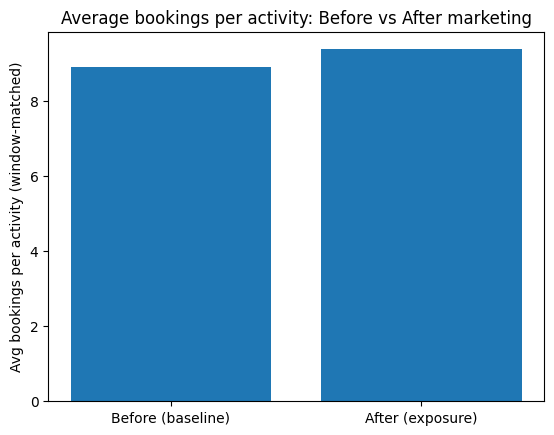

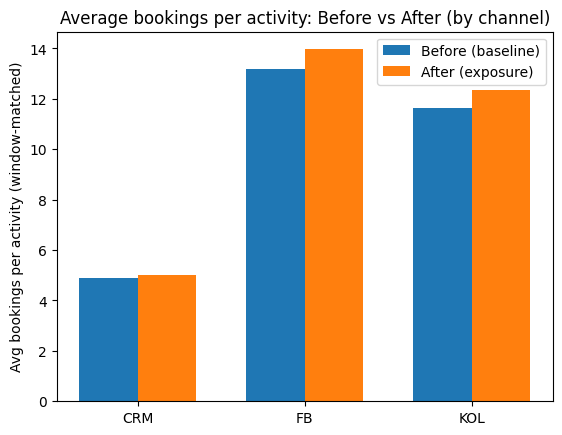

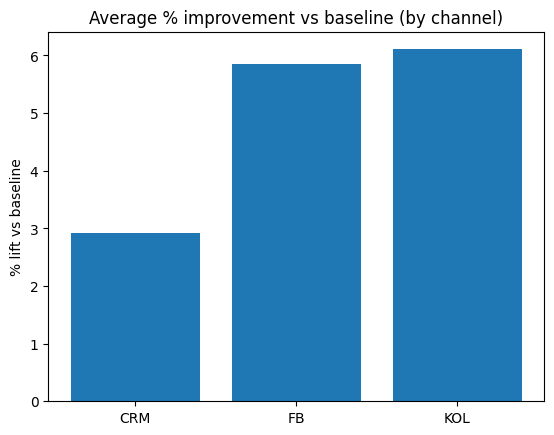

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) Make sure you have these from your previous steps ---
# lift_table: columns = ["activity_id", "bookings_during", "bookings_baseline", "lift"]
# mkt: must contain ["activity_id", "channel"] and be 1 row per activity_id (or we'll dedupe)

mkt_meta = mkt[["activity_id", "channel"]].drop_duplicates("activity_id")
perf = lift_table.merge(mkt_meta, on="activity_id", how="left")

# --- 2) Overall averages ---
overall_before = perf["bookings_baseline"].mean()
overall_after  = perf["bookings_during"].mean()
overall_lift   = overall_after - overall_before
overall_pct    = np.nan if overall_before == 0 else (overall_lift / overall_before) * 100

print(f"OVERALL avg before: {overall_before:.2f}")
print(f"OVERALL avg after : {overall_after:.2f}")
print(f"OVERALL lift      : {overall_lift:.2f}  ({overall_pct:.1f}%)")

# --- 3) Channel averages (mean per activity) ---
channel_summary = (
    perf.groupby("channel", as_index=False)
        .agg(
            avg_before=("bookings_baseline", "mean"),
            avg_after=("bookings_during", "mean"),
            n_activities=("activity_id", "nunique"),
        )
)

channel_summary["avg_lift"] = channel_summary["avg_after"] - channel_summary["avg_before"]
channel_summary["pct_lift"] = np.where(
    channel_summary["avg_before"] > 0,
    (channel_summary["avg_lift"] / channel_summary["avg_before"]) * 100,
    np.nan
)

print("\nCHANNEL summary (avg per activity):")
print(channel_summary.sort_values("avg_lift", ascending=False))

# --- 4) Plot: Overall before vs after ---
plt.figure()
plt.bar(["Before (baseline)", "After (exposure)"], [overall_before, overall_after])
plt.title("Average bookings per activity: Before vs After marketing")
plt.ylabel("Avg bookings per activity (window-matched)")
plt.show()

# --- 5) Plot: By channel (grouped bars) ---
# (no seaborn; no specified colors)
channels = channel_summary["channel"].tolist()
x = np.arange(len(channels))
w = 0.35

plt.figure()
plt.bar(x - w/2, channel_summary["avg_before"], width=w, label="Before (baseline)")
plt.bar(x + w/2, channel_summary["avg_after"],  width=w, label="After (exposure)")
plt.xticks(x, channels)
plt.title("Average bookings per activity: Before vs After (by channel)")
plt.ylabel("Avg bookings per activity (window-matched)")
plt.legend()
plt.show()

# --- 6) Optional: Plot improvement (% lift) by channel ---
plt.figure()
plt.bar(channel_summary["channel"], channel_summary["pct_lift"])
plt.title("Average % improvement vs baseline (by channel)")
plt.ylabel("% lift vs baseline")
plt.show()
